In [ ]:
import math
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import os
import time
from tqdm import tqdm, trange

import sys
sys.path.insert(0, "/home/palakons/shapevae")#files are relative to singularity home, coz the server is running singularity from there
from model.ptv3_based_model import PointVAE, VAEConfig


from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from pytorch3d.loss import chamfer_distance
import numpy as np

import wandb




# autoreload py
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

from experiment_runner import ExperimentConfig, run_training
from shapenet_dataset import ShapeNetDataset
from visualize import visualize_reconstructions, plot_pointclouds,visualize_interpolations

from model.ptv3_based_model import PointVAE as PointVAEPTv3, VAEConfig,check_voxel_collisions
from model.losses import repulsion_exp_loss,loss_fn_cd_plus_real_repulsion,loss_fn_cd,loss_fn_cd_plus_repulsion
from model.base_model import PointCloudAE

In [140]:
# raw mesh loader was very slow, precompute pointcloud as .npy instead
# precompute with ```python precompute_pointcloud.py --data-dir /ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/ --object-class 03001627 --output-dir ./sampled_poincloud/ --num-points 1024```

dataset = ShapeNetDataset(data_dir='./shapevae/sampled_poincloud_clip/', object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


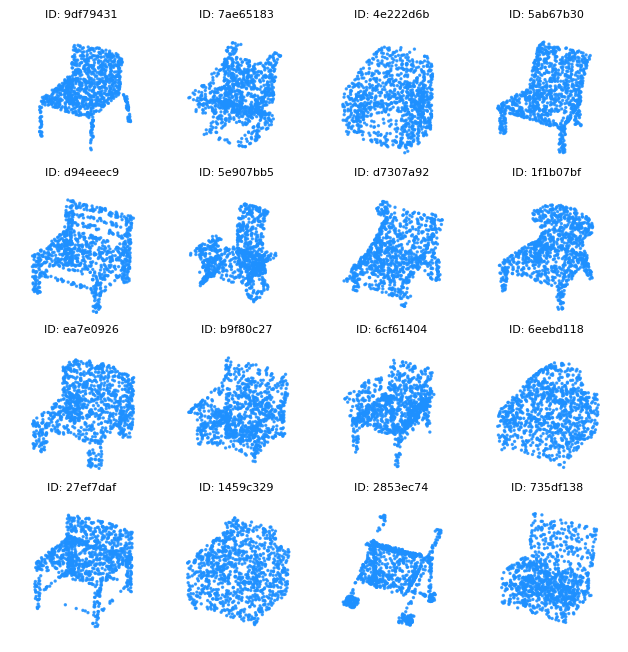

In [141]:

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list)
    break

## Setting up

In [142]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
batch_size = 16
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42
run_root="/shapevae_weights"

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)


device: cuda


## Align AE embeddings to CLIP embeddings with a projection head
- Pick one of the trained AEs from logged wandb runs on shared project (alephnir-vistec/shapevae)
- finetune a small projection head to align the AE latent space with CLIP embeddings of rendered views of the shapes.
- make sure record metrics on wandb and the checkpointing on "weigths" dir

In [143]:
from model.ptv3_based_model import PointVAE, VAEConfig,AECLIPProjectionHead,train_adaptor

In [144]:
import os, certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
import wandb
wandb.login()
api = wandb.Api()

In [146]:
model_adaptor = AECLIPProjectionHead(input_dim=z_dim, output_dim=512).to(device)
optimizer_adaptor = torch.optim.Adam(model_adaptor.parameters(), lr=lr)
loss_fn_adaptor = nn.MSELoss()

cfg_adaptor = ExperimentConfig(
    name="baseline_adaptor",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root=run_root,)


In [147]:
api = wandb.Api()
runs = api.runs("alephnir-vistec/shapevae")
# runs = api.runs("palakon-k/shapevae")

print(f"Found {len(runs)} runs in wandb project.")

for run in runs:
    #check for run_dir in run summary
    # print(run.name, run.id,run.summary['epoch'] )
    if "run_dir" in run.summary and run.summary['epoch'] == 100 and run.id== "giplbpyz": # only check checkpoints for runs that completed full training and are ptv3-based
        print("  run_dir:", run.summary["run_dir"].replace("/ist-nas/ist-share/vision/pratchp", ""))
        
        best_checkpoint_path = os.path.join(run.summary["run_dir"].replace("/ist-nas/ist-share/vision/pratchp", ""), "checkpoints/best.pt")

        # print("    Found checkpoint:", best_checkpoint_path)
        checkpoint = torch.load(best_checkpoint_path, map_location=device)
        # print(f"keys in checkpoint: {checkpoint.keys()}") #['epoch', 'best_val', 'model_state_dict', 'optimizer_state_dict', 'config']
        model_state_dict = checkpoint["model_state_dict"]
        if "ptv3" in run.name:
            cfg = VAEConfig(hidden_dim=64, latent_dim=128, num_points=num_points, variational=("vae" in run.name)   , grid_size=.01)
            point_ae_model = PointVAE(cfg=cfg).to(device)
        elif "baseline" in run.name:
            point_ae_model = PointCloudAE(z_dim=z_dim, num_points=num_points)
        else:
            print("    Unrecognized model type in run name. Skipping visualization.")
            continue

        point_ae_model.load_state_dict(model_state_dict)
        point_ae_model.to(device)
        point_ae_model.eval()
        # Visualize interpolations for this model
        # visualize_interpolations(point_ae_model, val_loader, device=device,title=run.name)
        
        
        print(f"Training adaptor for run: {run.name}")
        run_dir_adaptor, summary_adaptor = train_adaptor(
            config=cfg_adaptor,
            point_ae_model=point_ae_model,  # use the same model as point AE since we're only training a small projection head on top
            adaptor_model=model_adaptor,
            optimizer=optimizer_adaptor,
            loss_fn=loss_fn_adaptor,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
        )
    run_id = run.id
    print(f"Finished processing run {run_id}")
    break

Found 12 runs in wandb project.
Finished processing run ge932k3q


In [148]:
import clip
model_name = "ViT-B/32"
clip_model, preprocess = clip.load(model_name, device=device, jit=False)
#coome up with chaor attribute
keywords = ["tall", "short", "legged","swivel","round","flat","pointy","modern","thin","thick","a short legged modern chair that is thin and pointy","a short-legged chair","a tall-legged chair"]
keywords = ["a bean-bag-like chair","an oval chair", "a pointy chair","a spiky chair","a non-spiky chair","a very spiky chair", "a very pointy chair", "a very round chair", "a very flat chair", "a very swivel chair", "a very modern chair", "a very thin chair", "a very thick chair"]


def best_worst_pointclouds_by_keyword(
    point_ae_model,
    model_adaptor,
    clip_model,
    keywords,
    train_loader,
    device,
):
    clip_model.eval()
    clip_model.to(device)
    model_adaptor.eval()

    kw_tokens = clip.tokenize(keywords).to(device)                   # (K,)
    kw_clip_latents = clip_model.encode_text(kw_tokens).detach()    # (K,512)
    kw_norm = F.normalize(kw_clip_latents, dim=1).float()                    # (K,512)

    overall_min_sim = [float('inf')] * len(keywords)
    overall_max_sim = [float('-inf')] * len(keywords)
    pc_max = [None] * len(keywords)
    pc_min = [None] * len(keywords)

    for batch in train_loader:
        points = batch['points'].to(device)  # (B, N, 3)

        z = point_ae_model.encoder(points)  # (B, 1024)
        pred_clip_latent = model_adaptor(z)  # (B, 512)
        
        pred_norm = F.normalize(pred_clip_latent, dim=1).float()     # (B,512)
        sims = pred_norm @ kw_norm.t()                      # (B, K)

        # for keyword index k, column = sims[:, k]
        for k_idx, keyword in enumerate(keywords):
            col = sims[:, k_idx]                           # (B,)
            batch_min_sim, batch_min_idx = torch.min(col, dim=0)
            batch_max_sim, batch_max_idx = torch.max(col, dim=0)
            if batch_min_sim < overall_min_sim[k_idx]:
                overall_min_sim[k_idx] = batch_min_sim.item()
                pc_min[k_idx] = points[batch_min_idx].cpu().numpy()  # (N, 3)
            if batch_max_sim > overall_max_sim[k_idx]:
                overall_max_sim[k_idx] = batch_max_sim.item()
                pc_max[k_idx] = points[batch_max_idx].cpu().numpy()  # (N, 3)
    return zip(overall_min_sim, pc_min), zip(overall_max_sim, pc_max)

Results for train set:
Keyword: ['a bean-bag-like chair', 'an oval chair', 'a pointy chair', 'a spiky chair', 'a non-spiky chair', 'a very spiky chair', 'a very pointy chair', 'a very round chair', 'a very flat chair', 'a very swivel chair', 'a very modern chair', 'a very thin chair', 'a very thick chair']


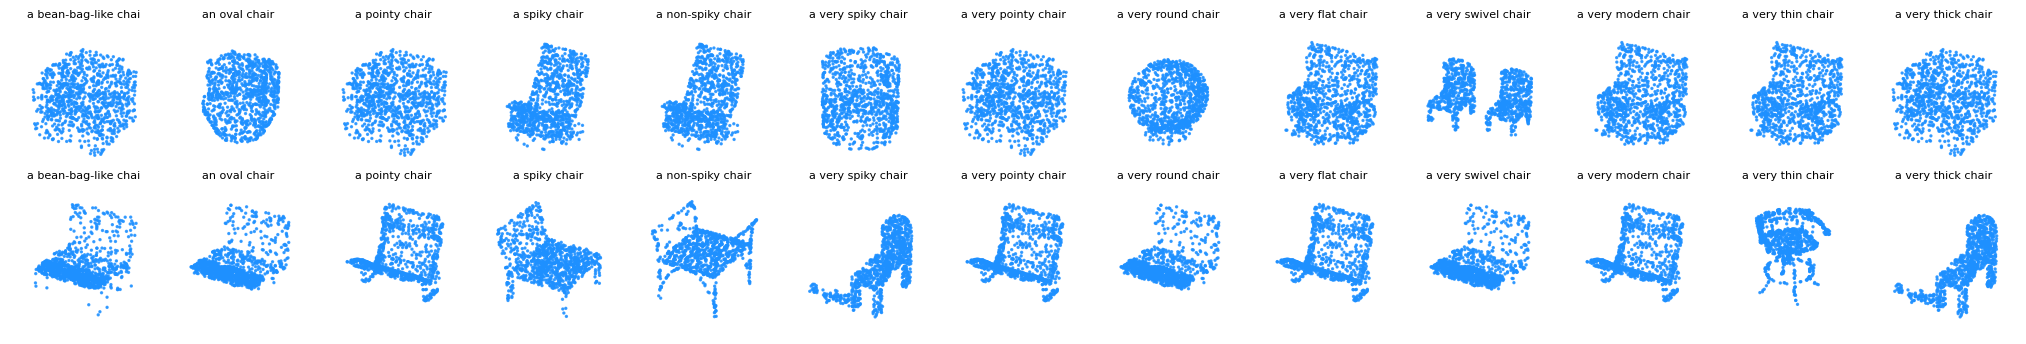

KeyError: 'clip_path'

In [183]:
#train and val
results = {}
for name, dataloader in [("train", train_loader), ("val", val_loader)]: 
    min_results, max_results = best_worst_pointclouds_by_keyword(
        point_ae_model=point_ae_model,
        model_adaptor=model_adaptor,
        clip_model=clip_model,
        keywords=keywords,
        train_loader=dataloader,
        device=device,
    )

    sim_points_pairs: Sequence[Tuple[str, torch.Tensor | np.ndarray]] = list(zip(keywords*2, [a[1] for a in list(min_results)+list(max_results)]))
    results[name] = sim_points_pairs

    print(f"Results for {name} set:")
    print(f"Keyword: {keywords}")
    plot_pointclouds(sim_points_pairs, n_cols=len(keywords),truncate_length=20)

In [ ]:
#get wandb run by id
run = api.run("alephnir-vistec/shapevae/giplbpyz")
print("  run_dir:", run.summary["run_dir"].replace("/ist-nas/ist-share/vision/pratchp", ""))
best_checkpoint_path = os.path.join(run.summary["run_dir"].replace("/ist-nas/ist-share/vision/pratchp", ""), "checkpoints/best.pt")

# print("    Found checkpoint:", best_checkpoint_path)
checkpoint = torch.load(best_checkpoint_path, map_location=device)
# print(f"keys in checkpoint: {checkpoint.keys()}") #['epoch', 'best_val', 'model_state_dict', 'optimizer_state_dict', 'config']
model_state_dict = checkpoint["model_state_dict"]
if "ptv3" in run.name:
    cfg = VAEConfig(hidden_dim=64, latent_dim=128, num_points=num_points, variational=("vae" in run.name)   , grid_size=.01)
    point_ae_model = PointVAE(cfg=cfg).to(device)
elif "baseline" in run.name:
    point_ae_model = PointCloudAE(z_dim=z_dim, num_points=num_points)
else:
    print("    Unrecognized model type in run name. Skipping visualization.")

point_ae_model.load_state_dict(model_state_dict)
point_ae_model.to(device)
point_ae_model.eval()

dataset_mesh = ShapeNetDataset(data_dir='./shapevae/sampled_pointcloud_clipmesh/', object_class='03001627')

train_set_mesh = Subset(dataset_mesh, train_idx)
val_set_mesh = Subset(dataset_mesh, val_idx)

train_loader_mesh = DataLoader(train_set_mesh, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader_mesh = DataLoader(
    val_set_mesh,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

model_adaptor_mesh = AECLIPProjectionHead(input_dim=z_dim, output_dim=512).to(device)
optimizer_adaptor_mesh = torch.optim.Adam(model_adaptor_mesh.parameters(), lr=lr)
loss_fn_adaptor = nn.MSELoss()

cfg_adaptor_mesh = ExperimentConfig(
    name="baseline_adaptor",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root=run_root,)



print(f"Training adaptor for run: {run.name}")
run_dir_adaptor_mesh, summary_adaptor_mesh = train_adaptor(
    config=cfg_adaptor_mesh,
    point_ae_model=point_ae_model,  # use the same model as point AE since we're only training a small projection head on top
    adaptor_model=model_adaptor_mesh,
    optimizer=optimizer_adaptor_mesh,
    loss_fn=loss_fn_adaptor,
    train_loader=train_loader_mesh,
    val_loader=val_loader_mesh,
    device=device,
)

  run_dir: /shapevae_weights/20260427-115805_palakons_baseline_cd
Training adaptor for run: baseline_cd


Adaptor Training:   0%|          | 0/100 [00:00<?, ?it/s]

Best adaptor model saved at: /shapevae_weights/best_adaptor.pt with val loss: 0.0199
Final adaptor model saved at: /shapevae_weights/final_adaptor.pt


Results for train set:
Keyword: ['a bean-bag-like chair', 'an oval chair', 'a pointy chair', 'a spiky chair', 'a non-spiky chair', 'a very spiky chair', 'a very pointy chair', 'a very round chair', 'a very flat chair', 'a very swivel chair', 'a very modern chair', 'a very thin chair', 'a very thick chair']


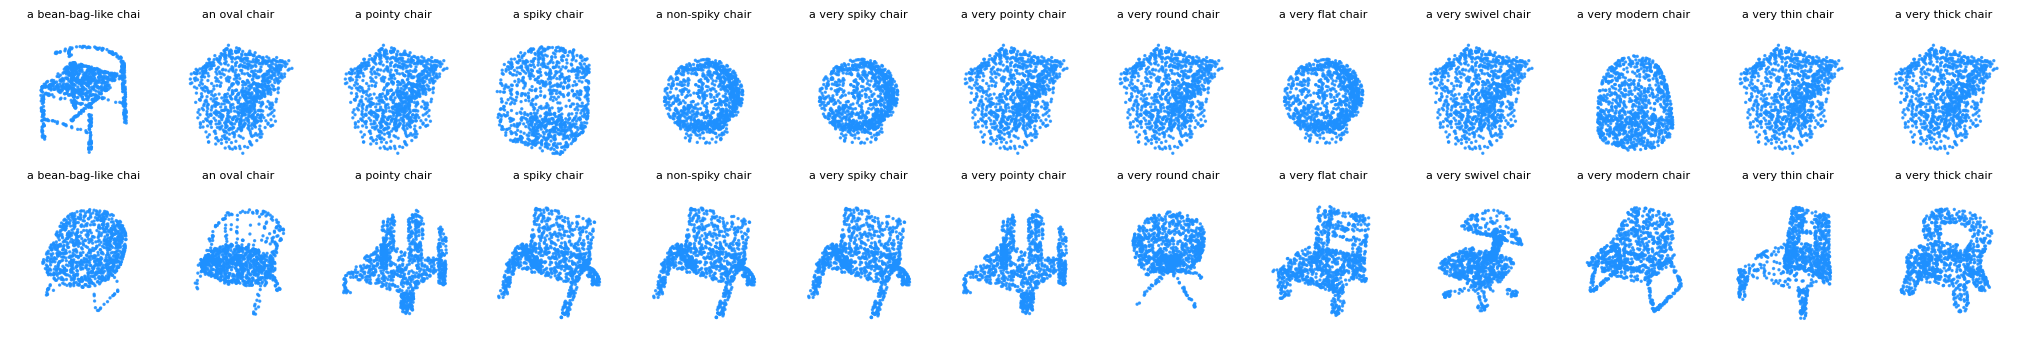

Results for val set:
Keyword: ['a bean-bag-like chair', 'an oval chair', 'a pointy chair', 'a spiky chair', 'a non-spiky chair', 'a very spiky chair', 'a very pointy chair', 'a very round chair', 'a very flat chair', 'a very swivel chair', 'a very modern chair', 'a very thin chair', 'a very thick chair']


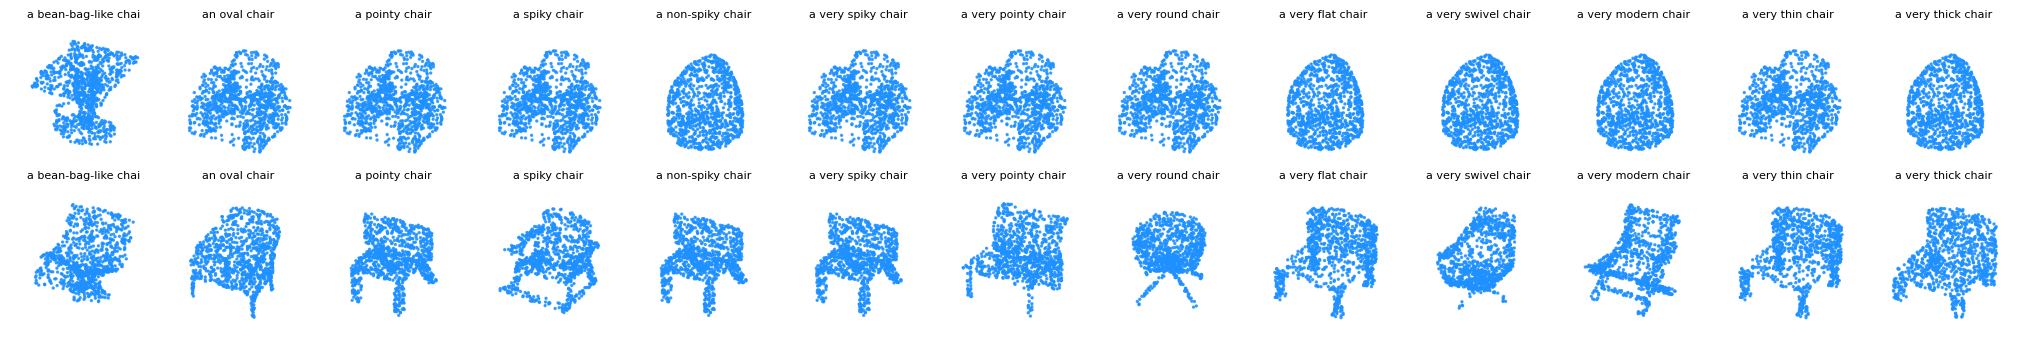

In [184]:
results_mesh = {}
for name, dataloader in [("train", train_loader_mesh), ("val", val_loader_mesh)]: 
    min_results, max_results = best_worst_pointclouds_by_keyword(
        point_ae_model=point_ae_model,
        model_adaptor=model_adaptor_mesh,
        clip_model=clip_model,
        keywords=keywords,
        train_loader=dataloader,
        device=device,
    )

    sim_points_pairs: Sequence[Tuple[str, torch.Tensor | np.ndarray]] = list(zip(keywords*2, [a[1] for a in list(min_results)+list(max_results)]))
    results_mesh[name] = sim_points_pairs

    print(f"Results for {name} set:")
    print(f"Keyword: {keywords}")
    plot_pointclouds(sim_points_pairs, n_cols=len(keywords),truncate_length=20)


In [185]:
#size of train vs val
print(f"Train set size: {len(train_set)}, Val set size: {len(val_set)}")

Train set size: 6100, Val set size: 678
